# Week 2 Assignment

### name: Lukas Linss
### student_id: 25332477
### id:7-7-7

In [55]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

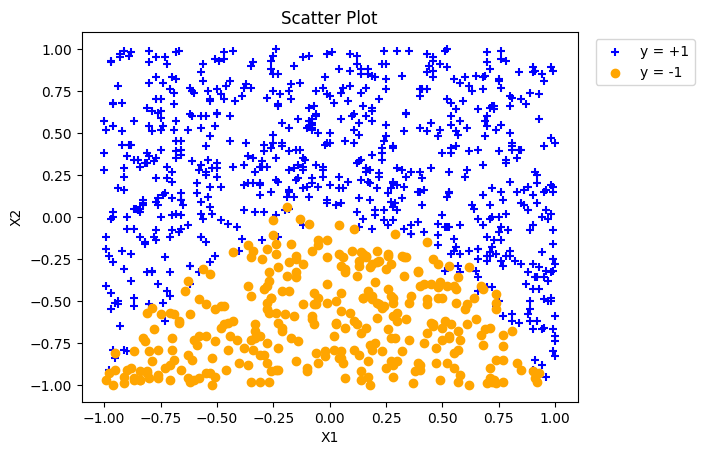

In [56]:
df = pd.read_csv('week_2_dataset.csv', skiprows=1, header=None, names=['X1', 'X2', 'Y'])

y_positive_df = df[df['Y'] == 1]
y_negative_df = df[df['Y'] == -1]

plt.scatter(x=y_positive_df['X1'], y=y_positive_df['X2'], color='blue', marker='+', label='y = +1')
plt.scatter(x=y_negative_df['X1'], y=y_negative_df['X2'], color='orange', marker='o', label='y = -1')

plt.title('Scatter Plot')
plt.xlabel('X1')
plt.ylabel('X2')

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()

prepare training and testing data

## LinearSVC

In [57]:
X = df[['X1', 'X2']].to_numpy()
y = df['Y'].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

c_values = [0.0001, 0.001, 0.01, 1, 10, 25, 50, 100]
svc_models = []
for c in c_values:
    model = LinearSVC(loss='hinge', C=c).fit(x_train, y_train)
    svc_models.append(model)
    theta_0, theta_1, theta_2 = *model.intercept_, *model.coef_[0]
    print(f'C={c} | θ_0={theta_0}, θ_1={theta_1}, θ_2={theta_2}')

C=0.0001 | θ_0=0.024699999999999906, θ_1=0.0021720000000000003, θ_2=0.026660999999999976
C=0.001 | θ_0=0.2470000000000002, θ_1=0.021720000000000024, θ_2=0.26661000000000007
C=0.01 | θ_0=0.5180342986571749, θ_1=0.1331700533894193, θ_2=1.3348333764762992
C=1 | θ_0=1.3153629549225128, θ_1=0.5123766177664978, θ_2=3.83444680004484
C=10 | θ_0=1.466287458165181, θ_1=0.5146197068031052, θ_2=4.191524966527332
C=25 | θ_0=1.4642242775641943, θ_1=0.4984642501658465, θ_2=4.217618117939018
C=50 | θ_0=1.4470810998763244, θ_1=0.5198076319529016, θ_2=4.2178312967031975
C=100 | θ_0=1.4491154351986384, θ_1=0.4768124167624225, θ_2=4.272948128358645


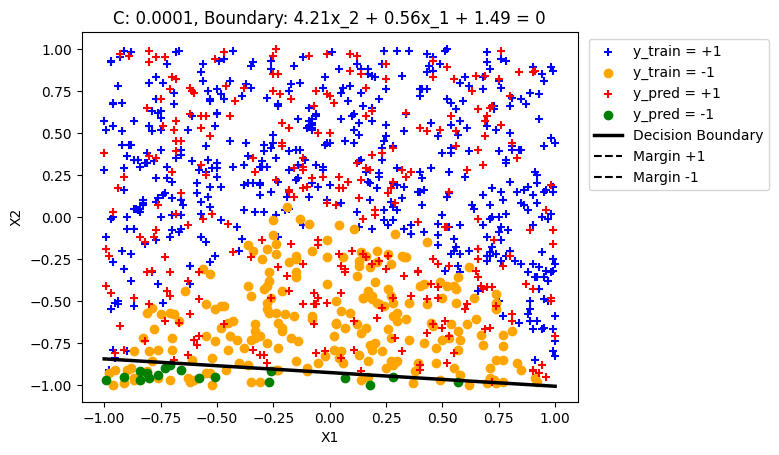

              precision    recall  f1-score   support

          -1       1.00      0.17      0.30       103
           1       0.70      1.00      0.82       197

    accuracy                           0.72       300
   macro avg       0.85      0.59      0.56       300
weighted avg       0.80      0.72      0.64       300



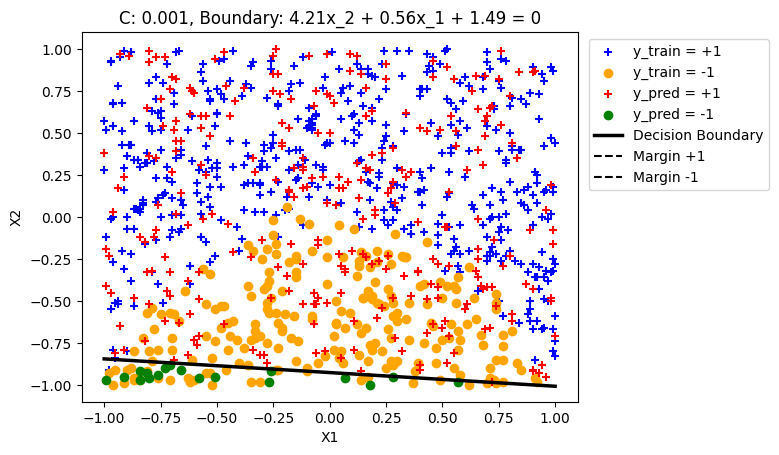

              precision    recall  f1-score   support

          -1       1.00      0.17      0.30       103
           1       0.70      1.00      0.82       197

    accuracy                           0.72       300
   macro avg       0.85      0.59      0.56       300
weighted avg       0.80      0.72      0.64       300



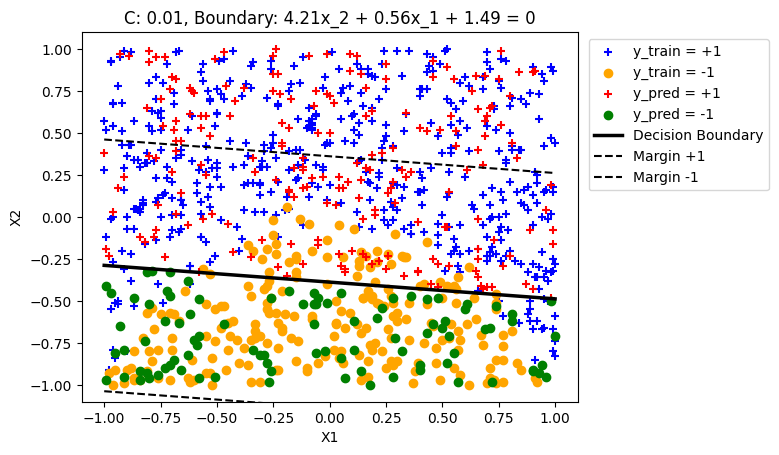

              precision    recall  f1-score   support

          -1       0.79      0.72      0.75       103
           1       0.86      0.90      0.88       197

    accuracy                           0.84       300
   macro avg       0.82      0.81      0.81       300
weighted avg       0.83      0.84      0.83       300



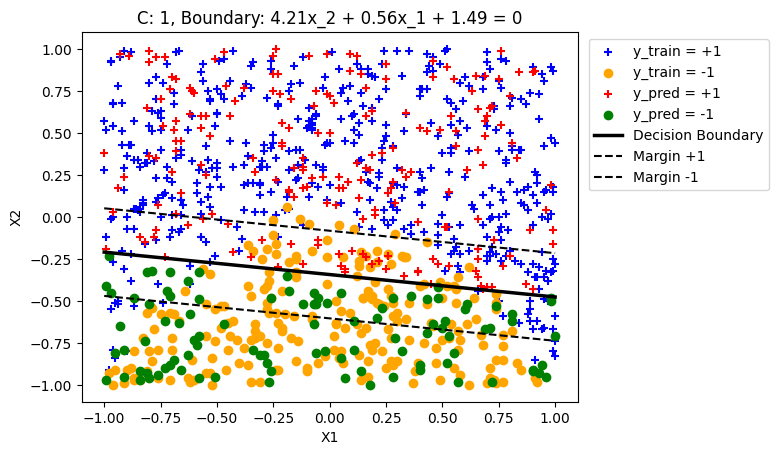

              precision    recall  f1-score   support

          -1       0.77      0.74      0.75       103
           1       0.87      0.88      0.87       197

    accuracy                           0.83       300
   macro avg       0.82      0.81      0.81       300
weighted avg       0.83      0.83      0.83       300



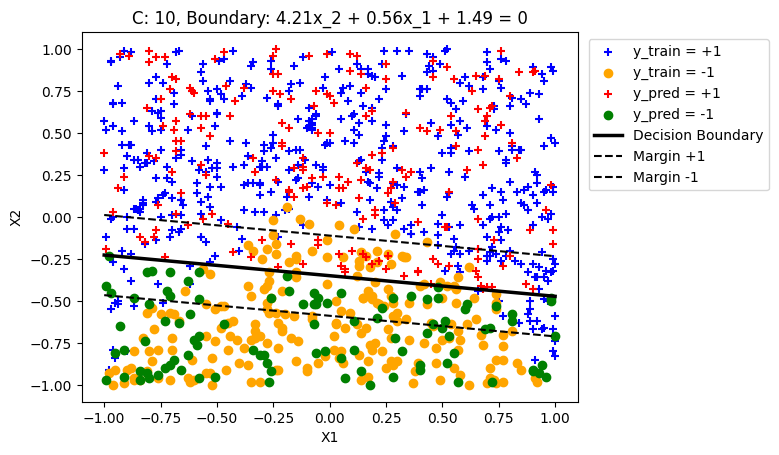

              precision    recall  f1-score   support

          -1       0.77      0.74      0.75       103
           1       0.87      0.88      0.87       197

    accuracy                           0.83       300
   macro avg       0.82      0.81      0.81       300
weighted avg       0.83      0.83      0.83       300



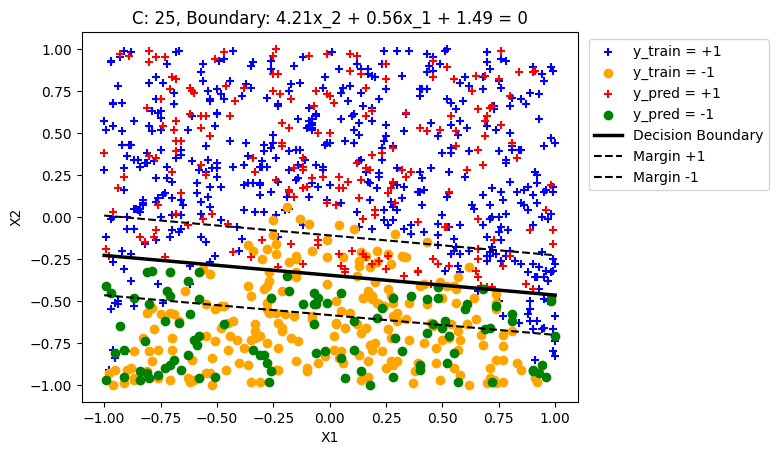

              precision    recall  f1-score   support

          -1       0.78      0.75      0.76       103
           1       0.87      0.89      0.88       197

    accuracy                           0.84       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.84      0.84      0.84       300



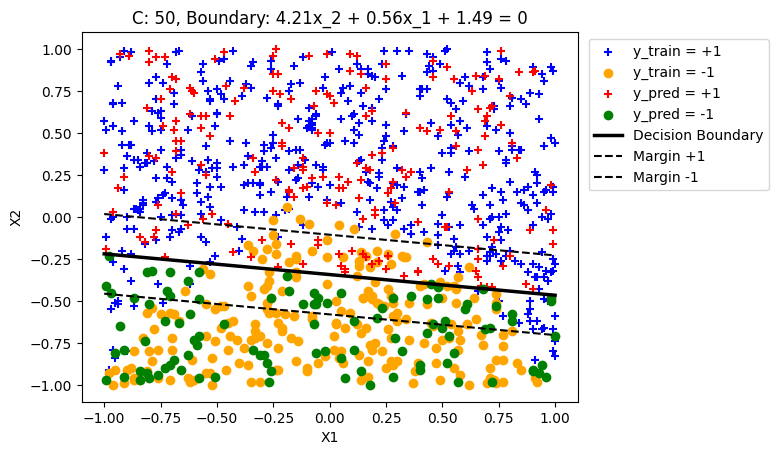

              precision    recall  f1-score   support

          -1       0.77      0.76      0.76       103
           1       0.87      0.88      0.88       197

    accuracy                           0.84       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.84      0.84      0.84       300



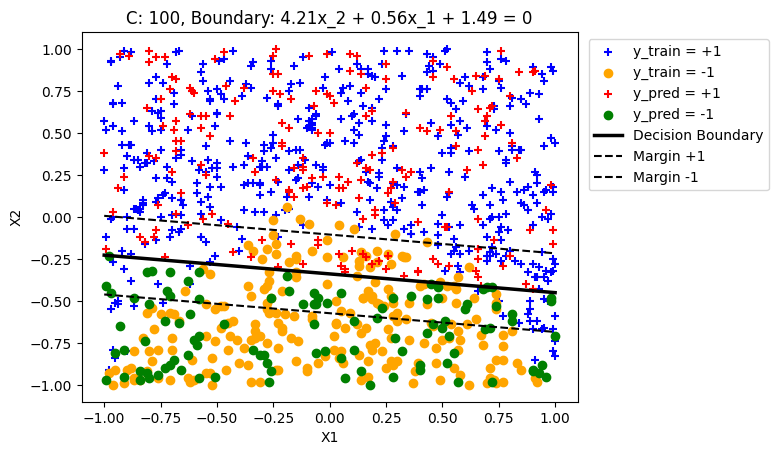

              precision    recall  f1-score   support

          -1       0.76      0.76      0.76       103
           1       0.87      0.87      0.87       197

    accuracy                           0.83       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.83      0.83      0.83       300



In [58]:
for model in svc_models:
    pred = model.predict(x_test)
    theta_0, theta_1, theta_2 = *model.intercept_, *model.coef_[0]
    x2 = lambda x1, offset: -x1 * theta_1 / theta_2 - (theta_0 + offset) / theta_2

    train_pos, train_neg = x_train[y_train == 1], x_train[y_train == -1]
    test_pos, test_neg = x_test[pred == 1], x_test[pred == -1]

    plt.scatter(x=train_pos[:, 0], y=train_pos[:, 1], color='blue', marker='+', label='y_train = +1')
    plt.scatter(x=train_neg[:, 0], y=train_neg[:, 1], color='orange', marker='o', label='y_train = -1')

    plt.scatter(x=test_pos[:, 0], y=test_pos[:, 1], marker='+', color='red', label='y_pred = +1')
    plt.scatter(x=test_neg[:, 0], y=test_neg[:, 1], marker='o', color='green', label='y_pred = -1')

    plt.plot([-1, 1], [x2(-1, 0), x2(1, 0)], color='black', linewidth='2.5', label='Decision Boundary')
    plt.plot([-1, 1], [x2(-1, 1), x2(1, 1)], '--', color='black', linewidth='1.5', label='Margin +1', )
    plt.plot([-1, 1], [x2(-1, -1), x2(1, -1)], '--', color='black', linewidth='1.5', label='Margin -1')

    plt.ylim(-1.1, 1.1)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(f'C: {model.embedding_table}, Boundary: {round(x2_coef, 2)}x_2 + {round(x1_coef, 2)}x_1 + {round(intercept, 2)} = 0')
    plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
    plt.show()
    print(classification_report(y_test, pred))
